## Isolation Forest implementation :


In [9]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("../Data/Intrusion_fixed_balanced.csv").drop(columns='timestamp')
df

,packet_per_sec,syn_ratio,avg_size,unique_ips,unique_ports
0,10.280275,0.013699,451.957300,10.097853,12.608575
1,138.861954,0.000000,219.466608,17.939299,21.844113
2,7.644659,0.000000,434.704712,6.751019,9.649578
3,1.411441,0.000000,210.309326,1.039275,1.453141
4,32.404182,0.000000,603.763231,7.270313,12.121961
...,...,...,...,...,...
3172,29.411382,0.003077,407.709027,24.325914,33.423357
3173,140.137340,0.001425,272.059024,18.823054,19.800527
3174,113.070546,0.000000,188.932390,36.169755,46.714885
3175,2.817701,0.000000,418.611453,7.973436,7.211412


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3177 entries, 0 to 3176
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   packet_per_sec  3177 non-null   float64
 1   syn_ratio       3177 non-null   float64
 2   avg_size        3177 non-null   float64
 3   unique_ips      3177 non-null   float64
 4   unique_ports    3177 non-null   float64
dtypes: float64(5)
memory usage: 124.2 KB


<Axes: >

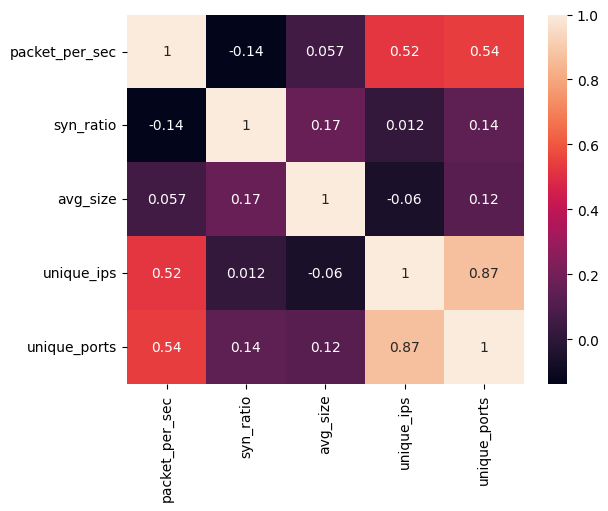

In [23]:
corr = df.corr()
sns.heatmap(data=corr, annot=True)


In [35]:
isolate = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
isolate.fit(df)

y_pred = isolate.predict(df)
index = np.where(y_pred == -1)
index

(array([  72,   73,  181,  213,  216,  237,  254,  257,  262,  300,  326,
         352,  413,  450,  476,  526,  552,  558,  604,  642,  667,  684,
         707,  738,  895,  917,  920,  978, 1019, 1026, 1044, 1099, 1115,
        1137, 1214, 1222, 1229, 1257, 1272, 1273, 1287, 1309, 1319, 1337,
        1370, 1429, 1460, 1495, 1505, 1510, 1621, 1651, 1697, 1753, 1817,
        1868, 1921, 1928, 1941, 1942, 1961, 1995, 2047, 2112, 2126, 2138,
        2146, 2159, 2310, 2313, 2315, 2492, 2530, 2587, 2671, 2677, 2684,
        2704, 2716, 2803, 2804, 2870, 2888, 2894, 2895, 3063, 3081, 3084,
        3098, 3113, 3119, 3132, 3137, 3144, 3149, 3156]),)

In [36]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(3177,))

In [37]:
df1 = pd.DataFrame(y_pred)
df1 

,0
0,1
1,1
2,1
3,1
4,1
...,...
3172,1
3173,1
3174,1
3175,1


In [38]:
df1.value_counts()

0 
 1    3081
-1      96
Name: count, dtype: int64

In [39]:
df

,packet_per_sec,syn_ratio,avg_size,unique_ips,unique_ports
0,10.280275,0.013699,451.957300,10.097853,12.608575
1,138.861954,0.000000,219.466608,17.939299,21.844113
2,7.644659,0.000000,434.704712,6.751019,9.649578
3,1.411441,0.000000,210.309326,1.039275,1.453141
4,32.404182,0.000000,603.763231,7.270313,12.121961
...,...,...,...,...,...
3172,29.411382,0.003077,407.709027,24.325914,33.423357
3173,140.137340,0.001425,272.059024,18.823054,19.800527
3174,113.070546,0.000000,188.932390,36.169755,46.714885
3175,2.817701,0.000000,418.611453,7.973436,7.211412


In [71]:
y_new = np.array([[210, 0.082, 230, 72, 190]])

In [72]:
preds = isolate.predict(y_new)

def anomalies_tagger(preds):
    for pred in preds:
        if pred == -1:
            return "Anomaly"
        elif pred == 1:
            return "Normal"
        else:
            return "UNKOWN"
anomalies_tagger(preds)

c:\HIDS\vnev\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


'Anomaly'

In [73]:
pred = (lambda x: "Anomaly" if x == -1 else "Normal")
pred(preds)

'Anomaly'

In [76]:
isolate.decision_function([[520, 0.35, 90, 220, 950]])

c:\HIDS\vnev\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


array([-0.19745408])